In [1]:
""" Sensitivity of dissolution rates at the HBR site to model setup """
import os
import xarray as xr
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utils import vert_interp
from shared_read_HBR import *
from matplotlib import rcParams
from matplotlib.patches import Patch
from string import ascii_lowercase

site = 'HBR'
prefix = '20250913'
suffix = ''

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

elm_interface = np.array([0, 1.75, 4.51, 9.06, 16.55, 28.91, 49.29, 82.89, 138.28])
elm_nodes = (elm_interface[1:] + elm_interface[:-1]) * 0.5
elm_thickness = np.diff(elm_interface)
if site == 'HBR':
    nlevsoi = 8
else:
    nlevsoi = 10

In [2]:
################################################
# Read all simulated data
################################################

# actual run
flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 
                     f'{prefix}_HBR_ICB20TRCNPRDCTCBC_{suffix}erw', 'run', 
                     f'{prefix}_HBR_ICB20TRCNPRDCTCBC_{suffix}erw.elm.h1.{yy}-01-01-00000.nc') \
         for yy in range(1980, 2022)]


hr = xr.open_mfdataset(flist)
tvec = pd.DatetimeIndex([pd.Timestamp(year=t.year, month=t.month, day=t.day)
                         for t in hr['time'].to_index()])

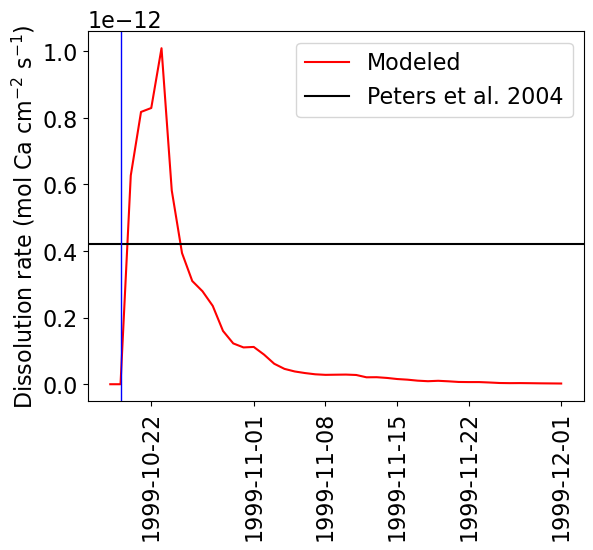

In [3]:
# dissolution rate: g m-2 s-1
# original applied primary mineral: g m-2 s-1, multiply by SSA = 1.6 m2 g-1
r_dissolv = pd.Series(hr['primary_dissolve'].sum(axis = 2).sum(axis = 1), tvec)
r_dissolv = r_dissolv.loc[(tvec >= pd.Timestamp('1999-10-18')) & (tvec <= pd.Timestamp('1999-12-01'))]
tot_applied = hr['primary_added'].sum(axis = 2).sum(axis = 1).sum().values * 86400 * 1.6

# unit conversion: g m-2 s-1 => mol Ca cm-2 s-1
r_dissolv = (r_dissolv / tot_applied) * (1 / 116.1617) * 1e-4

fig, ax = plt.subplots()
ax.plot(r_dissolv, label = 'Modeled', color = 'r')
ax.axhline(4.2*1e-13, label = 'Peters et al. 2004', color = 'k')
ax.axvline(pd.Timestamp('1999-10-19'), color = 'b', ls = '-', lw = 1, alpha = 1)
ax.legend()
ax.set_ylabel('Dissolution rate (mol Ca cm$^{-2}$ s$^{-1}$)')
plt.setp(ax.get_xticklabels(), rotation = 90)
plt.savefig(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'figures',
                         'sensitivity_HBR_dissolv.png'), dpi = 600., bbox_inches = 'tight')

In [4]:
hr.close()